In [1]:
import GEOparse

sample_id_to_title = {}

# Download and parse the series matrix
gse = GEOparse.get_GEO(geo="GSE161529", destdir="./")
# Access metadata and data
print(gse.metadata)
for gsm_name, gsm in gse.gsms.items():    
    sample_id_to_title[str(gsm.metadata['geo_accession'][0])] = str(gsm.metadata['title'][0])

print(sample_id_to_title)

15-Apr-2026 10:16:04 DEBUG utils - Directory ./ already exists. Skipping.
15-Apr-2026 10:16:04 INFO GEOparse - File already exist: using local version.
15-Apr-2026 10:16:04 INFO GEOparse - Parsing ./GSE161529_family.soft.gz: 
15-Apr-2026 10:16:04 DEBUG GEOparse - DATABASE: GeoMiame
15-Apr-2026 10:16:04 DEBUG GEOparse - SERIES: GSE161529
15-Apr-2026 10:16:04 DEBUG GEOparse - PLATFORM: GPL18573
15-Apr-2026 10:16:04 DEBUG GEOparse - SAMPLE: GSM4909253
15-Apr-2026 10:16:04 DEBUG GEOparse - SAMPLE: GSM4909254
15-Apr-2026 10:16:04 DEBUG GEOparse - SAMPLE: GSM4909255
15-Apr-2026 10:16:04 DEBUG GEOparse - SAMPLE: GSM4909256
15-Apr-2026 10:16:04 DEBUG GEOparse - SAMPLE: GSM4909257
15-Apr-2026 10:16:04 DEBUG GEOparse - SAMPLE: GSM4909258
15-Apr-2026 10:16:04 DEBUG GEOparse - SAMPLE: GSM4909259
15-Apr-2026 10:16:04 DEBUG GEOparse - SAMPLE: GSM4909260
15-Apr-2026 10:16:04 DEBUG GEOparse - SAMPLE: GSM4909261
15-Apr-2026 10:16:04 DEBUG GEOparse - SAMPLE: GSM4909262
15-Apr-2026 10:16:04 DEBUG GEOpars

{'title': ['scRNA-seq profiling of breast cancer tumors, BRCA1 mutant pre-neoplastic mammary gland cells and normal mammary gland cells'], 'geo_accession': ['GSE161529'], 'status': ['Public on Mar 19 2021'], 'submission_date': ['Nov 16 2020'], 'last_update_date': ['Sep 07 2024'], 'pubmed_id': ['33950524', '35322042'], 'summary': ['This study presents a single cell transcriptome map of nearly 430,000 cells encompassing normal breast at different hormonal stages, preneoplastic BRCA1+/- tissue, the major clinical subtypes of breast cancer, and matching pairs of tumors and involved axillary lymph nodes. Comparison of normal tissue specimens according to menopausal status primarily revealed changes in the stroma. Although there were modest changes in the microenvironment of preneoplastic BRCA1+/- versus normal tissue, a profound increase in infiltrating immune cells and a concomitant decrease in fibroblasts accompanied the transition to neoplasia. Single cell profiling of 32 tumors represen

In [2]:
from pathlib import Path
import scanpy as sc

import pandas as pd
from scipy.io import mmread
import anndata as ad

adatas = {}

def read_barcodes_and_matrix_files(barcodepath, matrixpath, features):
    barcodes = [f.name for f in Path(barcodepath).iterdir() if f.is_file()]
    print('Barcodes length = ' + str(len(barcodes)))

    # Read the sparse matrix
    matrix = mmread(matrixpath).T  # Transpose if rows are genes and columns are cells
    print(matrix.shape)

    # Create an AnnData object
    adata = sc.AnnData(X=matrix.tocsr())
    adata.obs_names = barcodes           # Assign barcodes to rows (observations)
    adata.var_names = features[1]        # Assign gene names to columns (variables)

    adata.var_names_make_unique()

    return adata

# Read the features
features = pd.read_csv("C:/Shriya/cancer_research/GSE161529_features.tsv/features.tsv", header=None, sep='\t')
print(features.shape)

barcodes_directory1 = "C:/Shriya/cancer_research/GSE161529_RAW/GSM4909253_N-PM0092-Total-barcodes.tsv"
matrix_directory1 = "C:/Shriya/cancer_research/GSE161529_RAW/GSM4909253_N-PM0092-Total-matrix.mtx/matrix.mtx"

barcodes_directory2 = "C:/Shriya/cancer_research/GSE161529_RAW/GSM4909254_N-PM0019-Total-barcodes.tsv"
matrix_directory2 = "C:/Shriya/cancer_research/GSE161529_RAW/GSM4909254_N-PM0019-Total-matrix.mtx/matrix.mtx"

barcodes_directory3 = "C:/Shriya/cancer_research/GSE161529_RAW/GSM4909255_N-N280-Epi-barcodes.tsv"
matrix_directory3 = "C:/Shriya/cancer_research/GSE161529_RAW/GSM4909255_N-N280-Epi-matrix.mtx/matrix.mtx"

barcodes_directory4 = "C:/Shriya/cancer_research/GSE161529_RAW/GSM4909256_N-PM0095-Epi-barcodes.tsv"
matrix_directory4 = "C:/Shriya/cancer_research/GSE161529_RAW/GSM4909256_N-PM0095-Epi-matrix.mtx/matrix.mtx"

barcodes_directory5 = "C:/Shriya/cancer_research/GSE161529_RAW/GSM4909257_N-PM0095-Total-barcodes.tsv"
matrix_directory5 = "C:/Shriya/cancer_research/GSE161529_RAW/GSM4909257_N-PM0095-Total-matrix.mtx/matrix.mtx"

barcodes_directory6 = "C:/Shriya/cancer_research/GSE161529_RAW/GSM4909258_N-NF-Epi-barcodes.tsv"
matrix_directory6 = "C:/Shriya/cancer_research/GSE161529_RAW/GSM4909258_N-NF-Epi-matrix.mtx/matrix.mtx"


adatas['GSM4909253'] = read_barcodes_and_matrix_files(barcodes_directory1, matrix_directory1, features)
adatas['GSM4909254'] = read_barcodes_and_matrix_files(barcodes_directory2, matrix_directory2, features)
adatas['GSM4909255'] = read_barcodes_and_matrix_files(barcodes_directory3, matrix_directory3, features)
adatas['GSM4909256'] = read_barcodes_and_matrix_files(barcodes_directory4, matrix_directory4, features)
adatas['GSM4909257'] = read_barcodes_and_matrix_files(barcodes_directory5, matrix_directory5, features)
adatas['GSM4909258'] = read_barcodes_and_matrix_files(barcodes_directory6, matrix_directory6, features)

adata = ad.concat(adatas, label="sample")
adata.obs_names_make_unique()
print(adata.obs["sample"].value_counts())

print(adata.shape)

(33538, 3)
Barcodes length = 4966
(4966, 33538)
Barcodes length = 7130
(7130, 33538)
Barcodes length = 1198
(1198, 33538)
Barcodes length = 9879
(9879, 33538)
Barcodes length = 7412
(7412, 33538)
Barcodes length = 3015
(3015, 33538)
sample
GSM4909256    9879
GSM4909257    7412
GSM4909254    7130
GSM4909253    4966
GSM4909258    3015
GSM4909255    1198
Name: count, dtype: int64
(33600, 33538)


c:\Shriya\cancer_research\code\.venv\Lib\site-packages\anndata\_core\anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


An AnnData object is a specialized data structure in Scanpy designed for matrix-like data, including single-cell RNA sequencing data. It efficiently organizes data and results, allowing you to perform complex analyses and visualizations. The AnnData object comprises several key components, each serving a specific role in storing data, metadata, or analysis results:

<pre>
X: the raw count matrix (cells x genes). X is left untouched by normalization or scaling and serves as the source of original counts.
obs: a dataframe with cell-level metadata, such as cell identifiers and experimental conditions. 
var: a dataframe with gene-level metadata
uns: unstructured annotations, often dictionaries containing parameters and results of analyses
obsm: multi-dimensional embeddings (e.g. PCA, UMAP, t-SNE)
varm: per-gene information such as principal components
layers: alternative representations of the count matrix derived from X (e.g. normalized, scaled) 
obsp: square matrices representing graphs

Good url to refer to : https://www.sc-best-practices.org/preprocessing_visualization/quality_control.html 
</pre>

In [3]:
adata.obs.head()

,sample
AAACCTGAGACTAGGC-1,GSM4909253
AAACCTGAGGACAGAA-1,GSM4909253
AAACCTGAGGATGTAT-1,GSM4909253
AAACCTGCAAGAGGCT-1,GSM4909253
AAACCTGGTAGCTTGT-1,GSM4909253


In [4]:
# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes.
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [5]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)
adata

AnnData object with n_obs × n_vars = 33600 × 33538
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

<pre>
As we can see, the function added a couple of additional columns to .var and .obs. We want to highlight a few of them here, more information on the different metrics can be found in the scanpy documentation:

n_genes_by_counts in .obs is the number of genes with positive counts in a cell,

total_counts is the total number of counts for a cell, this might also be known as library size, and

pct_counts_mt is the proportion of total counts for a cell which are mitochondrial.

We now plot the three QC covariates n_genes_by_counts, total_counts and pct_counts_mt per sample to assess how well the respective cells were captured.
</pre>

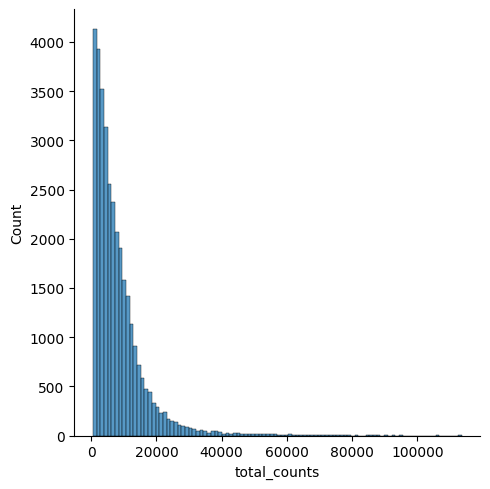

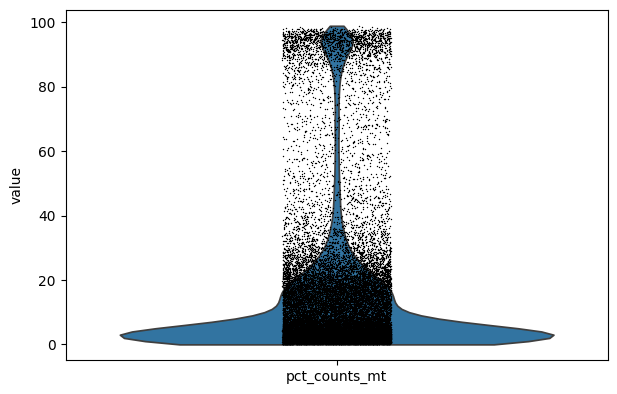

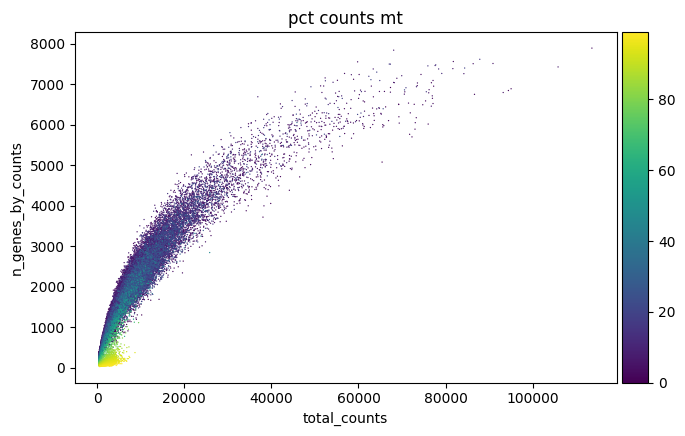

In [9]:
import seaborn as sns

p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)
# sc.pl.violin(adata, 'total_counts')
p2 = sc.pl.violin(adata, "pct_counts_mt")
p3 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

<pre>
The plots indicate that some cells have a relatively high percentage of mitochondrial counts which are often associated with cell degradation. But since number of counts per cell is sufficiently high and percentage of mitochondrial reads is for most cells below 20 % we can still process the data. Based on these plots, one could now also define manual thresholds for filtering cells. Instead, we will show QC with automatic thresholding and filtering based on MAD.

First, we define a function that takes a metric, i.e. a column in .obs and the number of MADs (nmad) that is still permissive within the filtering strategy.
</pre>

In [11]:
from scipy.stats import median_abs_deviation
import numpy as np

def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
        np.median(M) + nmads * median_abs_deviation(M) < M
    )
    return outlier

We now apply this function to the log1p_total_counts, log1p_n_genes_by_counts and pct_counts_in_top_20_genes QC covariates each with a threshold of 5 MADs.

In [12]:
adata.obs["outlier"] = (
    is_outlier(adata, "log1p_total_counts", 5)
    | is_outlier(adata, "log1p_n_genes_by_counts", 5)
    | is_outlier(adata, "pct_counts_in_top_20_genes", 5)
)
adata.obs.outlier.value_counts()

outlier
False    30413
True      3187
Name: count, dtype: int64

pct_counts_Mt is filtered with 3 MADs. Additionally, cells with a percentage of mitochondrial counts exceeding 8 % are filtered out.

In [13]:
adata.obs["mt_outlier"] = is_outlier(adata, "pct_counts_mt", 3) | (
    adata.obs["pct_counts_mt"] > 8
)
adata.obs.mt_outlier.value_counts()

mt_outlier
False    19953
True     13647
Name: count, dtype: int64

We now filter our AnnData object based on these two additional columns.

In [14]:
print(f"Total number of cells: {adata.n_obs}")
adata = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()

print(f"Number of cells after filtering of low quality cells: {adata.n_obs}")

Total number of cells: 33600
Number of cells after filtering of low quality cells: 19896


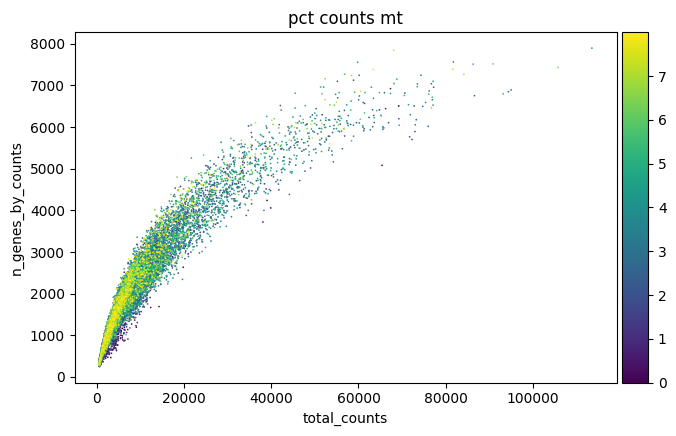

In [15]:
p1 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

* Doublet detection
<pre>
As a next step, we run a doublet detection algorithm. Identifying doublets is crucial as they can lead to misclassifications or distortions in downstream analysis steps. Scanpy contains the doublet detection method Scrublet [Wolock et al., 2019]. Scrublet predicts cell doublets using a nearest-neighbor classifier of observed transcriptomes and simulated doublets. scanpy.pp.scrublet() adds doublet_score and predicted_doublet to .obs. One can now either filter directly on predicted_doublet or use the doublet_score later during clustering to filter clusters with high doublet scores.
</pre>

In [16]:
sc.pp.scrublet(adata, batch_key="sample")

In [17]:
display(adata.obs.head())
print(f"Total number of cells before doublet filtering: {adata.n_obs}")
adata = adata[(~adata.obs.predicted_doublet)].copy()
print(f"Number of cells after filtering doublet cells: {adata.n_obs}")

,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,outlier,mt_outlier,n_genes,doublet_score,predicted_doublet
AAACCTGAGGACAGAA-1,GSM4909253,510,6.236370,1003,6.911747,22.731805,4,1.609438,0.398804,415,6.030685,41.375872,0,0.000000,0.000000,False,False,510,0.034642,False
AAACCTGAGGATGTAT-1,GSM4909253,1893,7.546446,7536,8.927580,22.744161,173,5.159055,2.295648,2582,7.856707,34.262208,5,1.791759,0.066348,False,False,1893,0.042017,False
AAACCTGCAAGAGGCT-1,GSM4909253,2595,7.861727,10366,9.246383,17.769631,408,6.013715,3.935944,2854,7.956827,27.532317,0,0.000000,0.000000,False,False,2594,0.105328,False
AAACCTGGTAGCTTGT-1,GSM4909253,734,6.599870,1628,7.395722,23.095823,43,3.784190,2.641278,481,6.177944,29.545455,0,0.000000,0.000000,False,False,733,0.019676,False
AAACCTGTCAAGGTAA-1,GSM4909253,677,6.519147,1708,7.443664,23.419204,45,3.828641,2.634660,658,6.490724,38.524590,1,0.693147,0.058548,False,False,675,0.011052,False


Total number of cells before doublet filtering: 19896
Number of cells after filtering doublet cells: 19780


* Normalization
<pre>
The next preprocessing step is normalization. A common approach is count depth scaling with subsequent log plus one (log1p) transformation. Count depth scaling normalizes the data to a “size factor” such as the median count depth in the dataset, ten thousand (CP10k) or one million (CPM, counts per million). The size factor for count depth scaling can be controlled via target_sum in pp.normalize_total. We are applying median count depth normalization with log1p transformation (AKA log1PF).
</pre>

In [18]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

In [19]:
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

In [20]:
adata.shape

(19780, 33538)

* Feature selection

<pre>
As a next step, we want to reduce the dimensionality of the dataset and only include the most informative genes. This step is commonly known as feature selection. The scanpy function pp.highly_variable_genes annotates highly variable genes by reproducing the implementations of Seurat [Satija et al., 2015], Cell Ranger [Zheng et al., 2017], and Seurat v3 [Stuart et al., 2019] depending on the chosen flavor.
</pre>

In [21]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample")

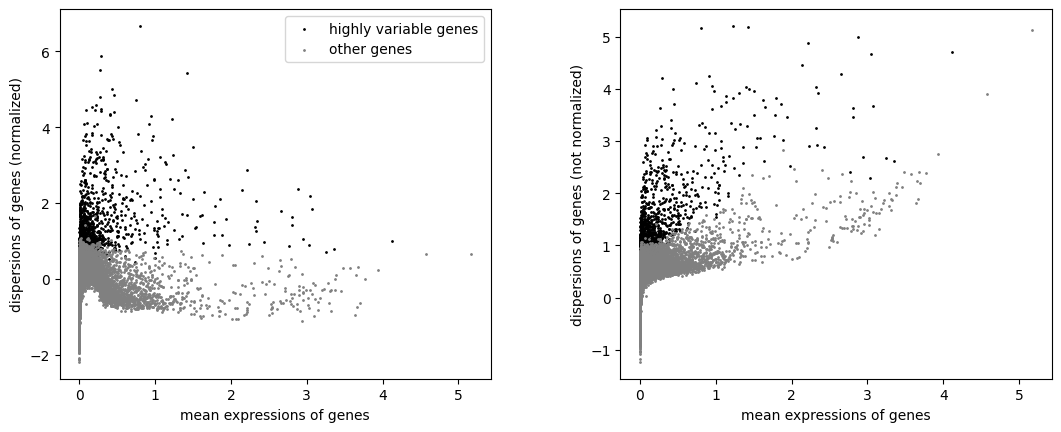

In [22]:
sc.pl.highly_variable_genes(adata)

* Dimensionality Reduction
Reduce the dimensionality of the data by running principal component analysis (PCA), which reveals the main axes of variation and denoises the data.

In [23]:
sc.tl.pca(adata)

Let us inspect the contribution of single PCs to the total variance in the data. This gives us information about how many PCs we should consider in order to compute the neighborhood relations of cells, e.g. used in the clustering function leiden() or tsne(). In our experience, there does not seem to be signifigant downside to overestimating the numer of principal components.

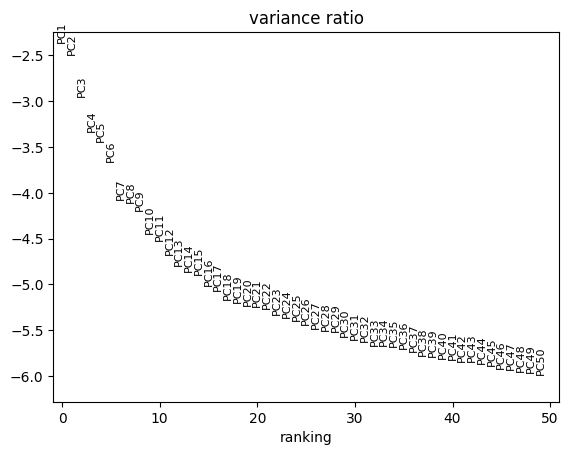

In [24]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

You can also plot the principal components to see if there are any potentially undesired features (e.g. batch, QC metrics) driving signifigant variation in this dataset. In this case, there isn’t anything too alarming, but it’s a good idea to explore this.

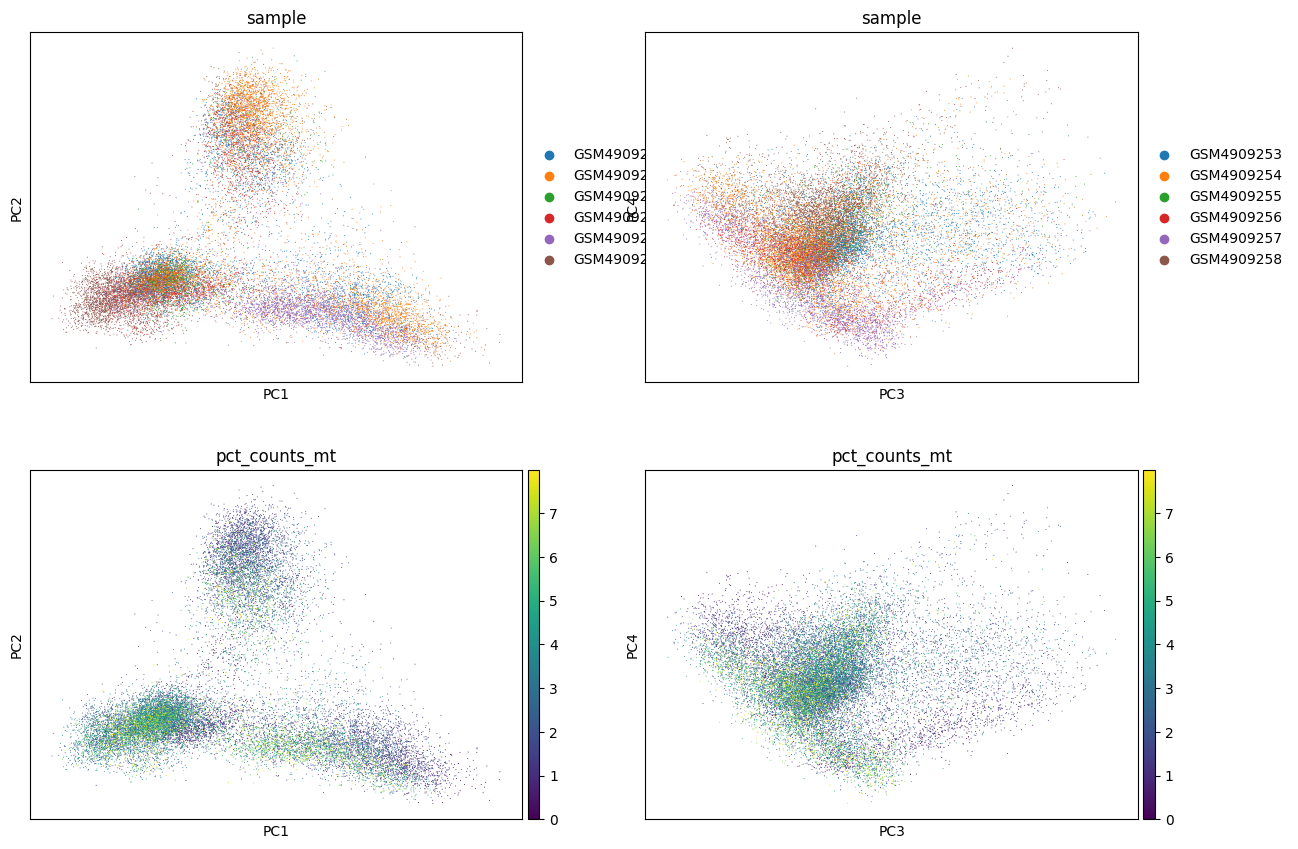

In [25]:
sc.pl.pca(
    adata,
    color=["sample", "sample", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=2,
)

Nearest neighbor graph construction and visualization
Let us compute the neighborhood graph of cells using the PCA representation of the data matrix.

In [26]:
sc.pp.neighbors(adata)

c:\Shriya\cancer_research\code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [27]:
sc.tl.umap(adata)

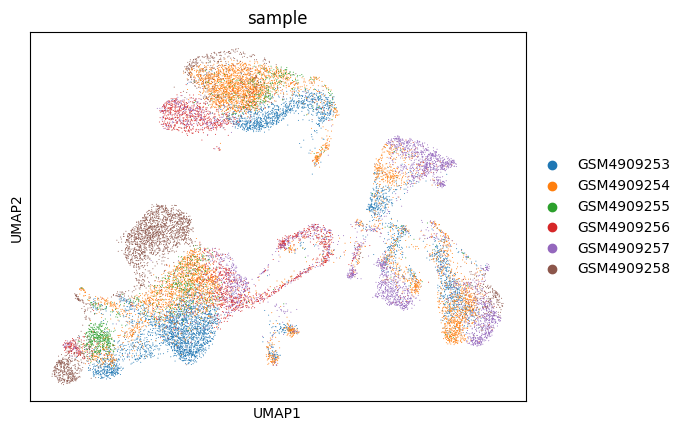

In [28]:
sc.pl.umap(
    adata,
    color="sample",
    # Setting a smaller point size to get prevent overlap
    size=2,
)

Clustering
As with Seurat and many other frameworks, we recommend the Leiden graph-clustering method (community detection based on optimizing modularity) [Traag et al., 2019]. Note that Leiden clustering directly clusters the neighborhood graph of cells, which we already computed in the previous section.

In [29]:
# Using the igraph implementation and a fixed number of iterations can be significantly faster,
# especially for larger datasets
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)

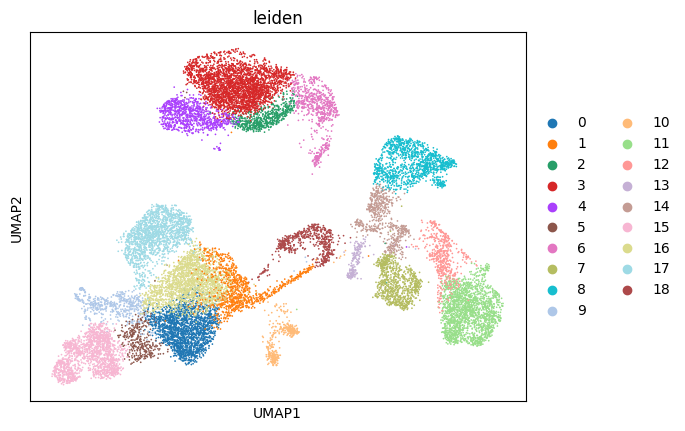

In [30]:
sc.pl.umap(adata, color=["leiden"])

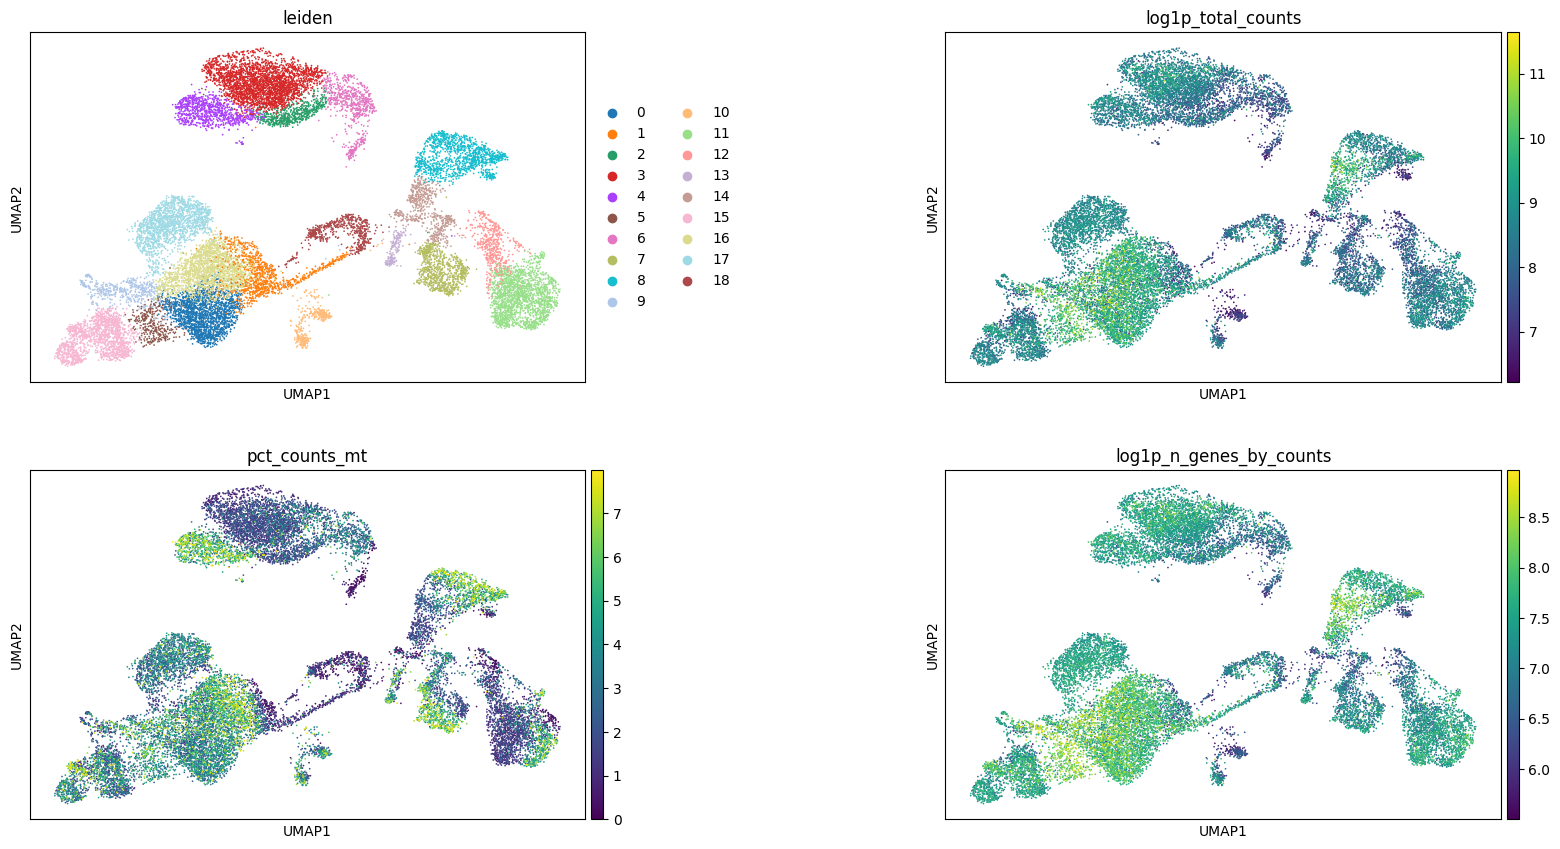

In [31]:
sc.pl.umap(
    adata,
    color=["leiden", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
    wspace=0.5,
    ncols=2,
)